In [3]:
!pip install -q transformers sentence-transformers ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.6 MB/s eta 0:00:00


In [4]:
import json
import numpy as np
import torch
import ipywidgets as widgets

from google.colab import files
from IPython.display import display

from transformers import pipeline
from sentence_transformers import SentenceTransformer, CrossEncoder

In [5]:
uploaded = files.upload()

Saving dev-v1.1.json to dev-v1.1.json
Saving train-v1.1.json to train-v1.1.json


In [6]:
def load_squad_contexts(path):
    contexts = []

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)["data"]

    for article in data:
        for paragraph in article["paragraphs"]:
            contexts.append(paragraph["context"])

    return list(set(contexts))


train_contexts = load_squad_contexts("train-v1.1.json")
val_contexts = load_squad_contexts("dev-v1.1.json")

documents = train_contexts + val_contexts

print("Total documents:", len(documents))

Total documents: 20958


In [7]:
retriever = SentenceTransformer("all-MiniLM-L6-v2")

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

qa_model = pipeline(
    "question-answering",
    model="distilbert-base-uncased-distilled-squad",
    device=0 if torch.cuda.is_available() else -1
)

print("Models loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Models loaded.


In [8]:
doc_embeddings = retriever.encode(
    documents,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Embeddings ready.")

Batches:   0%|          | 0/655 [00:00<?, ?it/s]

Embeddings ready.


In [9]:
def retrieve(question, top_k=20):
    q_embedding = retriever.encode(
        question,
        convert_to_tensor=True
    )

    scores = torch.nn.functional.cosine_similarity(
        q_embedding.unsqueeze(0),
        doc_embeddings
    )

    top_idx = torch.topk(scores, k=top_k).indices

    return [documents[i] for i in top_idx]

In [10]:
def answer_question(question):
    candidates = retrieve(question)

    pairs = [(question, doc) for doc in candidates]

    rerank_scores = reranker.predict(pairs)

    best_idx = np.argmax(rerank_scores)

    best_context = candidates[best_idx]

    result = qa_model(
        question=question,
        context=best_context
    )

    return {
        "answer": result["answer"],
        "score": result["score"],
        "context": best_context
    }

In [11]:
question_box = widgets.Text(
    placeholder="Ask anything from dataset...",
    description="Question:",
    layout=widgets.Layout(width="90%")
)

button = widgets.Button(
    description="Search Answer",
    button_style="success"
)

output = widgets.Output()


def on_click(b):
    with output:
        output.clear_output()

        q = question_box.value.strip()

        if not q:
            print("Enter question.")
            return

        result = answer_question(q)

        print("Answer:", result["answer"])
        print("Confidence:", round(result["score"], 4))
        print("\nSource:\n")
        print(result["context"][:800], "...")


button.on_click(on_click)

display(question_box, button, output)

Text(value='', description='Question:', layout=Layout(width='90%'), placeholder='Ask anything from dataset...'…

Button(button_style='success', description='Search Answer', style=ButtonStyle())

Output()

In [12]:
eval_examples = []

with open("dev-v1.1.json", "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

for article in data:
    for paragraph in article["paragraphs"]:
        context = paragraph["context"]

        for qa in paragraph["qas"]:
            if qa["answers"]:
                eval_examples.append({
                    "question": qa["question"],
                    "answer": qa["answers"][0]["text"],
                    "context": context
                })

print("Evaluation samples:", len(eval_examples))

Evaluation samples: 10570


In [13]:
import re
from collections import Counter


def normalize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.strip()


def exact_match(pred, truth):
    return int(normalize(pred) == normalize(truth))


def qa_f1(pred, truth):
    pred_tokens = normalize(pred).split()
    truth_tokens = normalize(truth).split()

    if len(pred_tokens) == 0 or len(truth_tokens) == 0:
        return 0

    common = Counter(pred_tokens) & Counter(truth_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(truth_tokens)

    return 2 * precision * recall / (precision + recall)

In [14]:
def retrieval_metrics(question, true_context, k=5):
    candidates = retrieve(question, top_k=k)

    hits = [doc == true_context for doc in candidates]

    relevant_retrieved = sum(hits)

    precision = relevant_retrieved / k
    recall = 1 if relevant_retrieved > 0 else 0

    rr = 0
    for rank, hit in enumerate(hits, start=1):
        if hit:
            rr = 1 / rank
            break

    return precision, recall, rr

In [15]:
sample_eval = eval_examples[:200]

qa_accuracy = []
qa_em = []
qa_f1_scores = []

retrieval_precisions = []
retrieval_recalls = []
retrieval_rr = []

confidences = []


for i, item in enumerate(sample_eval):
    question = item["question"]
    true_answer = item["answer"]
    true_context = item["context"]

    # retrieval metrics
    p, r, rr = retrieval_metrics(question, true_context)

    retrieval_precisions.append(p)
    retrieval_recalls.append(r)
    retrieval_rr.append(rr)

    # QA
    result = answer_question(question)

    pred_answer = result["answer"]

    em = exact_match(pred_answer, true_answer)
    f1 = qa_f1(pred_answer, true_answer)

    qa_em.append(em)
    qa_f1_scores.append(f1)
    qa_accuracy.append(1 if f1 > 0.5 else 0)

    confidences.append(result["score"])

    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(sample_eval)}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 20/200
Processed 40/200
Processed 60/200
Processed 80/200
Processed 100/200
Processed 120/200
Processed 140/200
Processed 160/200
Processed 180/200
Processed 200/200


In [17]:
def f1_score(pred, truth):
    pred_tokens = normalize(pred).split()
    truth_tokens = normalize(truth).split()

    common = Counter(pred_tokens) & Counter(truth_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(truth_tokens)

    return 2 * precision * recall / (precision + recall)

In [18]:
sample_eval = eval_examples[:100]

ems = []
f1s = []
confidences = []

for item in sample_eval:
    result = answer_question(item["question"])

    pred = result["answer"]
    truth = item["answer"]

    ems.append(exact_match(pred, truth))
    f1s.append(f1_score(pred, truth))
    confidences.append(result["score"])

print("Exact Match:", np.mean(ems))
print("F1 Score:", np.mean(f1s))
print("Avg Confidence:", np.mean(confidences))

Exact Match: 0.54
F1 Score: 0.5821904761904763
Avg Confidence: 0.7262349473153882


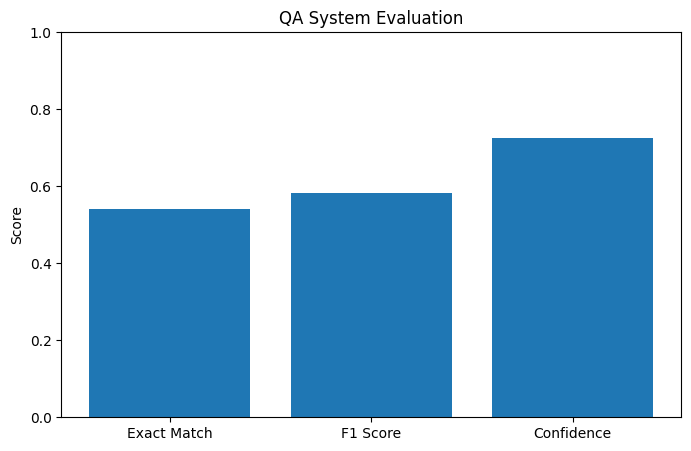

In [19]:
import matplotlib.pyplot as plt

metrics = {
    "Exact Match": np.mean(ems),
    "F1 Score": np.mean(f1s),
    "Confidence": np.mean(confidences)
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0,1)
plt.title("QA System Evaluation")
plt.ylabel("Score")
plt.show()

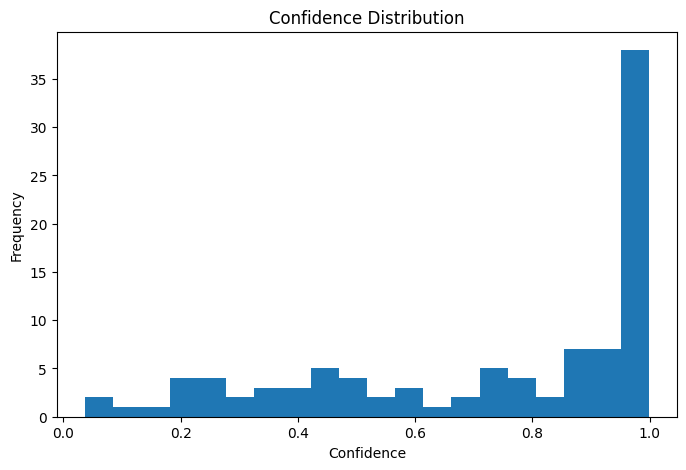

In [20]:
plt.figure(figsize=(8,5))
plt.hist(confidences, bins=20)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

RETRIEVAL PERFORMANCE METRICS
Precision@5: 0.1650
Recall@5: 0.8250
MRR (Mean Reciprocal Rank): 0.5693


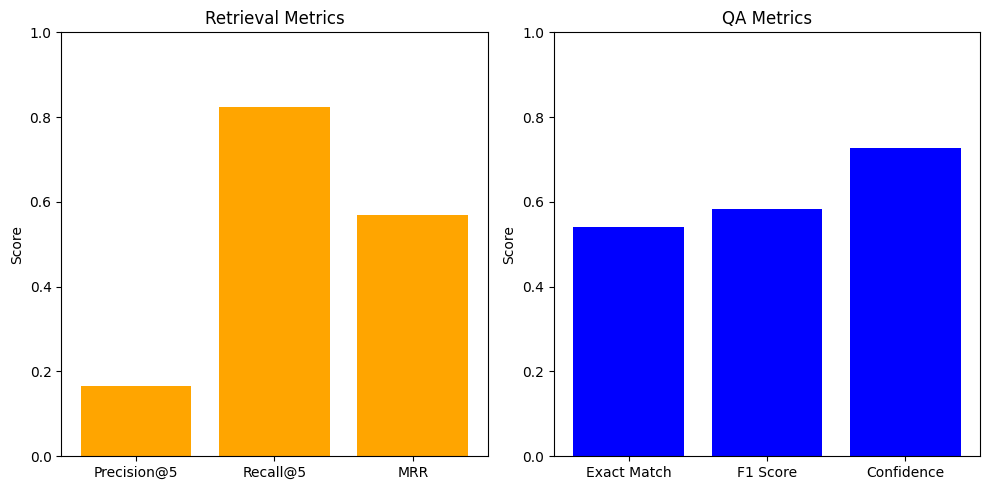

In [21]:
# Calculate and display retrieval metrics
import numpy as np

# Check if the variables exist (from Cell 20)
if 'retrieval_precisions' in locals():
    print("=" * 50)
    print("RETRIEVAL PERFORMANCE METRICS")
    print("=" * 50)
    print(f"Precision@5: {np.mean(retrieval_precisions):.4f}")
    print(f"Recall@5: {np.mean(retrieval_recalls):.4f}")
    print(f"MRR (Mean Reciprocal Rank): {np.mean(retrieval_rr):.4f}")
    print("=" * 50)
else:
    print("⚠️ Error: Please run the evaluation loop (Cell 20) first to generate the metrics.")
# Optional: Create a visualization
plt.figure(figsize=(10, 5))

# Subplot 1: Retrieval metrics
plt.subplot(1, 2, 1)
retrieval_metrics = {
    'Precision@5': np.mean(retrieval_precisions),
    'Recall@5': np.mean(retrieval_recalls),
    'MRR': np.mean(retrieval_rr)
}
plt.bar(retrieval_metrics.keys(), retrieval_metrics.values(), color='orange')
plt.ylim(0, 1)
plt.title('Retrieval Metrics')
plt.ylabel('Score')

# Subplot 2: QA metrics (from earlier)
plt.subplot(1, 2, 2)
qa_metrics = {
    'Exact Match': np.mean(ems),
    'F1 Score': np.mean(f1s),
    'Confidence': np.mean(confidences)
}
plt.bar(qa_metrics.keys(), qa_metrics.values(), color='blue')
plt.ylim(0, 1)
plt.title('QA Metrics')
plt.ylabel('Score')

plt.tight_layout()
plt.show()